# Transfer Matrix Optimization with MORBO (Full)
This mirrors the original TransferMatrix Ax notebook but swaps in `MorboOptimizer` to optimize Jsc and AVT.

In [1]:
%matplotlib inline
import os, torch, pprint
import pandas as pd
import matplotlib.pyplot as plt

from optimpv.general.FitParams import FitParam
from optimpv.TransferMatrix.TransferMatrixAgent import TransferMatrixAgent
from optimpv.morbo import MorboOptimizer


## Define parameters (same as original Ax example)

In [2]:
params = []
params.append(FitParam(name='d_3', value=80e-9, bounds=[40e-9, 200e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='int', type='range', display_name='d_3', unit='m'))
params.append(FitParam(name='d_6', value=10e-9, bounds=[5e-9, 20e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='int', type='range', display_name='d_6', unit='m'))
params.append(FitParam(name='d_7', value=100e-9, bounds=[50e-9, 200e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='int', type='range', display_name='d_7', unit='m'))
params.append(FitParam(name='d_8', value=10e-9, bounds=[5e-9, 20e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='int', type='range', display_name='d_8', unit='m'))
params.append(FitParam(name='d_9', value=100e-9, bounds=[50e-9, 200e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='int', type='range', display_name='d_9', unit='m'))
# params.append(FitParam(name='nk_3', value='PCE10_FOIC_1to1', values=['PCE10_FOIC_1to1','P3HTPCBM_BHJ','PM6Y6Brabec'], log_scale=False, rescale=False, value_type='str', type='choice', display_name='nk_3', unit=''))
print('Total free params:', len([p for p in params if p.type != "fixed"]))


Total free params: 5


## Stack configuration (same data as original)

In [3]:
layers = ['SiOx', 'ITO', 'ZnO', 'PCE10_FOIC_1to1', 'MoOx', 'Ag', 'MoOx', 'LiF', 'MoOx', 'LiF', 'Air']
thicknesses = [0, 100e-9, 30e-9, 100e-9, 9e-9, 8e-9, 100e-9, 100e-9, 100e-9, 100e-9, 100e-9]
mat_dir = os.path.join(os.path.abspath('..'), 'Data', 'matdata')
lambda_min, lambda_max, lambda_step, x_step = 350e-9, 800e-9, 1e-9, 1e-9
activeLayer = 3
spectrum = os.path.join(mat_dir, 'AM15G.txt')
photopic_file = os.path.join(mat_dir, 'photopic_curve.txt')


## Instantiate agent

In [4]:
TMAgent = TransferMatrixAgent(
    params=params,
    y=[None, None],
    layers=layers,
    thicknesses=thicknesses,
    lambda_min=lambda_min,
    lambda_max=lambda_max,
    lambda_step=lambda_step,
    x_step=x_step,
    activeLayer=activeLayer,
    spectrum=spectrum,
    mat_dir=mat_dir,
    photopic_file=photopic_file,
    exp_format=['Jsc', 'AVT'],
    metric=[None, None],
    loss=[None, None],
    threshold=[4, 0.1],
    minimize=[False, False],
    name='TM',
)
print('Metrics:', TMAgent.all_agent_metrics)


Metrics: ['TM_Jsc', 'TM_AVT']


## Configure and run MorboOptimizer
Budget mirrors the Ax example (~90 evals). Reference point should be worse than expected for each metric.


In [5]:
reference_point = [0.0, 0.0]
optimizer = MorboOptimizer(
    params=params,
    agents=TMAgent,
    max_evals=90,
    batch_size=4,
    n_initial_points=10,
    reference_point=reference_point,
    tr_hparam_overrides={
        'min_tr_size': 5,
        'max_tr_size': 100,
        'raw_samples': 1024,
    },
    torch_dtype=torch.double,
    torch_device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    seed=1234,
    verbose=True,
)
result = optimizer.optimize()
print('Finished MORBO run. Evaluations:', len(result['metric_history_raw']))


# of tabu points: 0
# of invalid centers: 0
New metrics for center: tensor([[102.6901,   0.6403]], dtype=torch.float64)
Fitting a model
# of tabu points: 0
# of invalid centers: 1
New metrics for center: tensor([[133.9576,   0.4966]], dtype=torch.float64)
Fitting a model
# of tabu points: 0
# of invalid centers: 2
New metrics for center: tensor([[182.1797,   0.2752]], dtype=torch.float64)
Fitting a model
# of tabu points: 0
# of invalid centers: 3
New metrics for center: tensor([[112.9792,   0.5557]], dtype=torch.float64)
Fitting a model
# of tabu points: 0
# of invalid centers: 4
New metrics for center: tensor([[159.0817,   0.3494]], dtype=torch.float64)
Fitting a model
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
Time spent on sampling: 3.4 seconds
Time spent on HVI computations: 21.1 seconds
Number of points se

c:\Users\fifof\miniconda3\envs\optimenv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Time spent on sampling: 3.4 seconds
Time spent on HVI computations: 42.9 seconds
Number of points selected from each TR: [1, 0, 2, 1, 0]
Time spent on generating candidates: 46.3 seconds
# of tabu points: 0
# of invalid centers: 4
SUCCESS: hv ratio: 1.0033236796069724
New metrics for center: tensor([[102.6901,   0.6403]], dtype=torch.float64)
Fitting a model
Num points in TR: 29
length: 0.8
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 39
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 25
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Time spent on model fitting: 1.7 seconds
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
Time spent on sampling: 3.0 seconds
Time spent on HVI computations: 43.

c:\Users\fifof\miniconda3\envs\optimenv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Time spent on sampling: 3.2 seconds
Time spent on HVI computations: 44.8 seconds
Number of points selected from each TR: [0, 0, 0, 0, 4]
Time spent on generating candidates: 48.1 seconds
# of tabu points: 0
# of invalid centers: 4
Fitting a model
# of tabu points: 0
# of invalid centers: 4
Fitting a model
# of tabu points: 0
# of invalid centers: 4
Fitting a model
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 23
length: 0.8
Time spent on model fitting: 2.1 seconds
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4


...

Time spent on sampling: 3.6 seconds
Time spent on HVI computations: 68.0 seconds
Number of points selected from each TR: [2, 0, 0, 1, 1]
Time spent on generating candidates: 71.6 seconds
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 43
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
# of tabu points: 0
# of invalid centers: 4
New metrics for center: tensor([[137.8105,   0.4825]], dtype=torch.float64)
Fitting a model
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 33
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 37
length: 0.8
Time spent on model fitting: 2.8 seconds
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
New metrics for center: tensor([[111.9919,   0.6048]], dtype=torch.float64)
Fitting a model
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of inva

c:\Users\fifof\miniconda3\envs\optimenv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Time spent on sampling: 3.6 seconds
Time spent on HVI computations: 70.9 seconds
Number of points selected from each TR: [1, 0, 2, 1, 0]
Time spent on generating candidates: 74.6 seconds
# of tabu points: 0
# of invalid centers: 4
New metrics for center: tensor([[119.8604,   0.5725]], dtype=torch.float64)
Fitting a model
Num points in TR: 51
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
# of tabu points: 0
# of invalid centers: 4
New metrics for center: tensor([[102.6901,   0.6403]], dtype=torch.float64)
Fitting a model
Num points in TR: 46
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 35
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Time spent on model fitting: 3.7 seconds
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4


c:\Users\fifof\miniconda3\envs\optimenv\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Time spent on sampling: 4.3 seconds
Time spent on HVI computations: 82.9 seconds
Number of points selected from each TR: [1, 0, 2, 0, 1]
Time spent on generating candidates: 87.3 seconds
# of tabu points: 0
# of invalid centers: 4
New metrics for center: tensor([[131.8050,   0.5220]], dtype=torch.float64)
Fitting a model
Num points in TR: 62
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
# of tabu points: 0
# of invalid centers: 4
SUCCESS: hv ratio: 1.0012133709209021
New metrics for center: tensor([[119.8604,   0.5725]], dtype=torch.float64)
Fitting a model
Num points in TR: 54
length: 0.8
# of tabu points: 0
# of invalid centers: 4
Fitting a model
# of tabu points: 0
# of invalid centers: 4
Fitting a model
Num points in TR: 42
length: 0.8
Time spent on model fitting: 3.6 seconds
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of tabu points: 0
# of invalid centers: 4
# of ta

## Convert history to DataFrame (metrics and parameters)

In [6]:
# Metrics
metric_cols = TMAgent.all_agent_metrics
df_metrics = pd.DataFrame(result['metric_history_raw'].numpy(), columns=metric_cols)
df_metrics['eval'] = range(len(df_metrics))

# Parameters (descaled to physical units)
X_hist = result['X_history'].numpy()
param_dicts = [optimizer._vector_to_param_dict(x) for x in X_hist]
df_params = pd.DataFrame(param_dicts)
df_params = TMAgent.rescale_dataframe(df_params.copy(), TMAgent.params)
df_params['eval'] = range(len(df_params))
df_metrics.head(), df_params.head()


(       TM_Jsc    TM_AVT  eval
 0  133.957615  0.496632     0
 1  182.179734  0.275191     1
 2  171.161359  0.298501     2
 3  151.076012  0.378952     3
 4  140.639488  0.380832     4,
             d_3           d_6           d_7           d_8           d_9  eval
 0  7.250304e-08  1.131845e-08  5.078723e-08  1.817024e-08  1.459412e-07     0
 1  1.822170e-07  1.774395e-08  1.555970e-07  8.517194e-09  6.530878e-08     1
 2  1.482661e-07  5.866211e-09  1.218689e-07  1.425246e-08  9.402527e-08     2
 3  1.166917e-07  1.603808e-08  1.717469e-07  8.818649e-09  1.922346e-07     3
 4  9.149998e-08  7.265352e-09  1.390601e-07  1.240375e-08  1.699035e-07     4)

## Plot metric traces

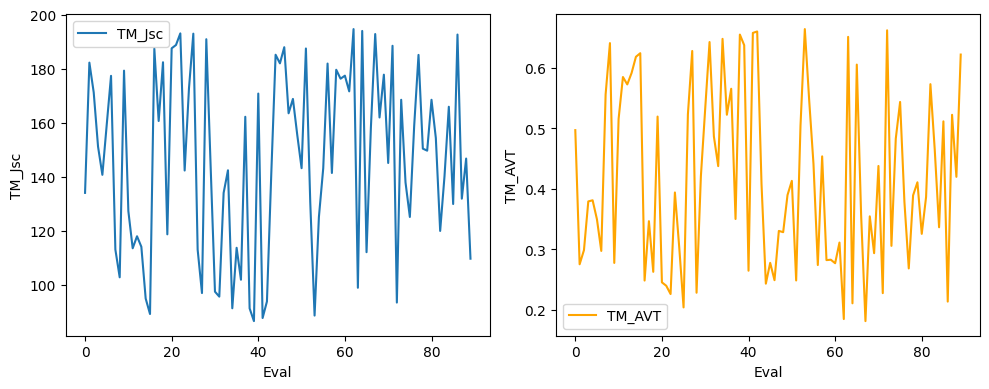

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(df_metrics['eval'], df_metrics[metric_cols[0]], label=metric_cols[0])
ax[0].set_xlabel('Eval')
ax[0].set_ylabel(metric_cols[0])
ax[0].legend()
ax[1].plot(df_metrics['eval'], df_metrics[metric_cols[1]], label=metric_cols[1], color='orange')
ax[1].set_xlabel('Eval')
ax[1].set_ylabel(metric_cols[1])
ax[1].legend()
fig.tight_layout()
plt.show()


## Plot explored parameters vs eval (example dimensions)

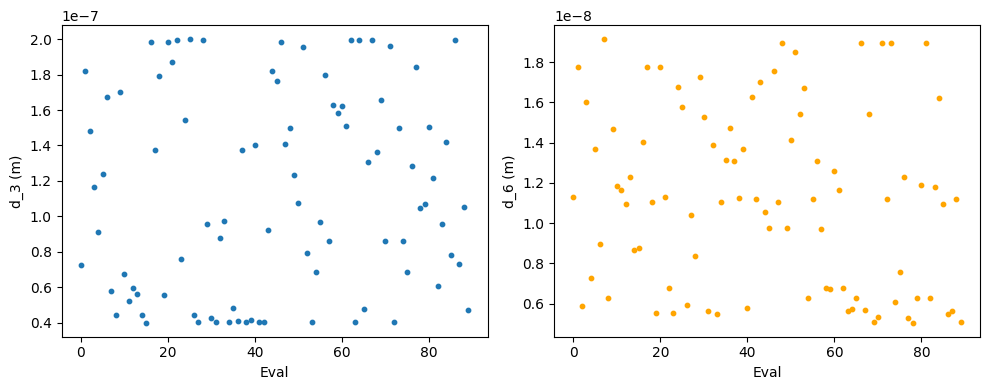

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].scatter(df_params['eval'], df_params['d_3'], s=10)
ax[0].set_xlabel('Eval')
ax[0].set_ylabel('d_3 (m)')
ax[1].scatter(df_params['eval'], df_params['d_6'], s=10, color='orange')
ax[1].set_xlabel('Eval')
ax[1].set_ylabel('d_6 (m)')
fig.tight_layout()
plt.show()


## Plot final Pareto front

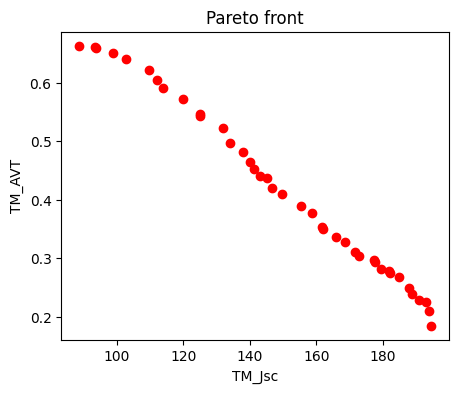

In [13]:
pareto_Y = result.get('pareto_Y_raw', [])
if pareto_Y and pareto_Y[-1]:
    py = pd.DataFrame(pareto_Y[-1], columns=metric_cols)
    plt.figure(figsize=(5,4))
    plt.scatter(py[metric_cols[0]], py[metric_cols[1]], c='red')
    plt.xlabel(metric_cols[0])
    plt.ylabel(metric_cols[1])
    plt.title('Pareto front')
    plt.show()
else:
    print('No Pareto points to plot.')
